# Probabilistic Simulations and Distributions
In this section, we simulate rolling two six-sided dice 10,000 times. By summing the results, we can observe the frequency of each possible sum (2 through 12).

Key concepts illustrated here:
* **Discrete Random Variables**: The sum of two dice.
* **Probability Mass Function (PMF)**: Visualized using the bar plot of normalized value counts.
* **Cumulative Distribution Function (CDF)**: Calculated using `np.cumsum`, showing the probability that a sum is less than or equal to a certain value.

In [1]:
import pandas as pd

In [2]:
import random

In [3]:
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [4]:
len(L)

10000

In [5]:
L[:5]

[11, 6, 7, 6, 4]

In [6]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [7]:
import numpy as np
np.cumsum(s)

,count
2,0.0251
3,0.0804
4,0.1647
5,0.2741
6,0.4135
7,0.5774
8,0.7148
9,0.8276
10,0.9136
11,0.9716


<Axes: >

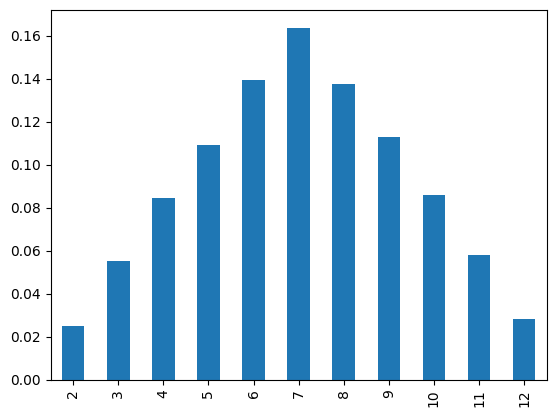

In [8]:
s.plot(kind='bar')

<Axes: >

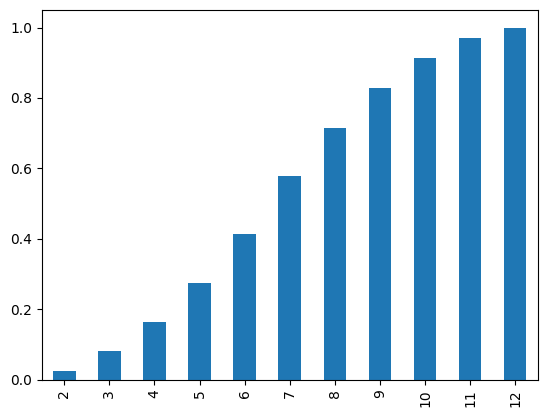

In [9]:
np.cumsum(s).plot(kind='bar')

# Parametric Density Estimation

### What is Parametric Density Estimation?
Parametric estimation assumes that the data follows a specific known distribution (like the Normal/Gaussian distribution).

**The Process:**
1. **Select a Distribution**: Based on the histogram shape, we assume the data is Gaussian.
2. **Estimate Parameters**: We calculate the sample mean ($\mu$) and standard deviation ($\sigma$).
3. **Fit the Model**: Using these parameters, we define a probability density function (PDF) that 'fits' the data.

In the code below, we compare the actual histogram of a generated sample against the PDF of a Normal distribution.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

sample = normal(loc=50, scale=5,size=1000)

In [11]:
sample.mean()

np.float64(50.22888279752799)

(array([ 18.,  35.,  85., 144., 203., 211., 168.,  78.,  47.,  11.]),
 array([36.28584035, 39.06392989, 41.84201943, 44.62010898, 47.39819852,
        50.17628806, 52.9543776 , 55.73246714, 58.51055668, 61.28864623,
        64.06673577]),
 <BarContainer object of 10 artists>)

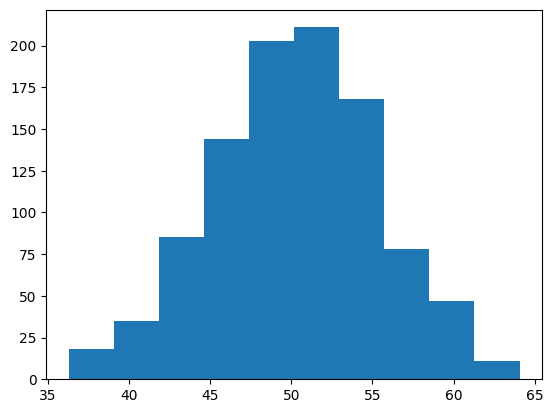

In [12]:
# plot histogram to understand the distribution of data
plt.hist(sample,bins=10)

In [13]:
# calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

In [14]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(60, 12)

In [15]:
values = np.linspace(sample.min(),sample.max(),100)

In [16]:
sample.max()

np.float64(64.06673576788022)

In [17]:
probabilities = [dist.pdf(value) for value in values]

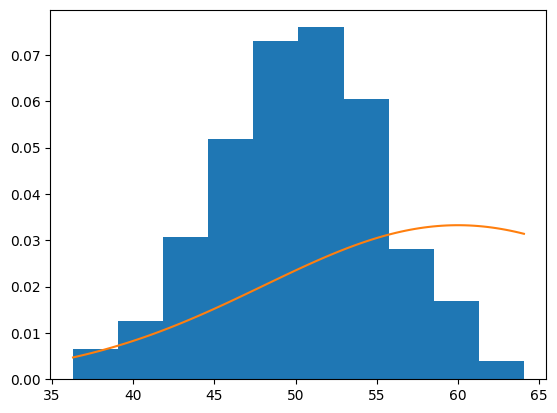

In [18]:
# plot the histogram and pdf
plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

/tmp/ipykernel_963/1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

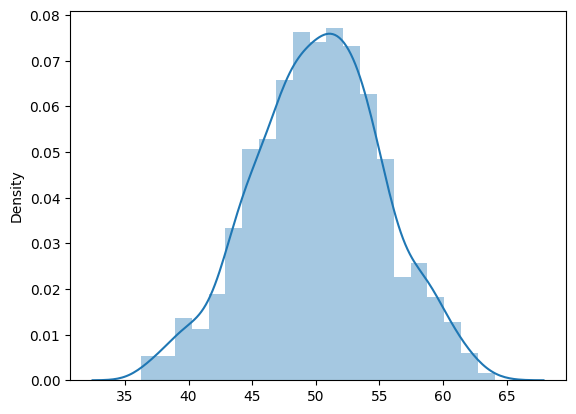

In [19]:
import seaborn as sns
sns.distplot(sample)

# KDE

### Kernel Density Estimation (KDE)
KDE is a **non-parametric** way to estimate the probability density function of a random variable. Unlike parametric estimation, it does not assume a specific distribution shape (like Gaussian).

**Why use KDE?**
* It is useful when your data is **multi-modal** (has multiple peaks), as seen in the code where we combine two different normal distributions.
* It smooths out the noise in a histogram to provide a continuous curve.
* **Bandwidth ($h$)**: The most important parameter. A small bandwidth leads to an undersmoothed (wiggly) estimate, while a large bandwidth leads to an oversmoothed estimate.

In [20]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [21]:
sample

array([20.99176291, 16.32610457, 14.97281228, 16.69136086, 21.39322729,
       25.41162437, 16.35760957, 20.75511551, 18.08324469, 19.87737123,
       19.27436283, 20.4471485 , 17.91984806, 20.78896368, 22.17103387,
       24.92683897, 18.67771038, 19.59375017, 23.65857654, 15.56823744,
       15.70988363, 18.68961123, 20.28910264, 17.32230337, 20.10733132,
       21.33692438, 26.43657862, 17.05480282, 11.51873642, 26.1346298 ,
       25.51624329, 27.86653634, 21.49699395, 21.05948148, 19.64850979,
       28.36109551, 23.52101789, 18.12873005, 18.9116187 , 21.99228363,
       17.4510782 , 18.27880261, 19.71608582, 24.31467176,  9.81364223,
       22.63148442, 27.72499399, 26.84997999, 24.29129223, 19.91352179,
       22.82060445, 17.11071382, 21.89212816, 23.27472401, 14.05861237,
       26.78345436, 12.13706767, 22.04012568, 13.59325447, 22.43328457,
       24.96381304, 18.49143143, 27.13530777, 19.2398544 , 34.07867378,
       12.90560611, 15.71143095, 31.71561916, 19.06269434, 19.67

(array([ 1.,  1.,  1.,  3.,  6.,  9.,  9., 17.,  9., 12., 24., 13., 25.,
        34., 21., 27., 20., 18.,  9., 12., 15.,  8.,  9., 10., 13., 11.,
        28., 28., 40., 38., 44., 60., 41., 60., 56., 47., 66., 30., 42.,
        22., 24., 12., 11.,  6.,  4.,  2.,  0.,  1.,  0.,  1.]),
 array([ 6.03092823,  7.05060838,  8.07028853,  9.08996869, 10.10964884,
        11.12932899, 12.14900914, 13.16868929, 14.18836944, 15.20804959,
        16.22772974, 17.24740989, 18.26709004, 19.2867702 , 20.30645035,
        21.3261305 , 22.34581065, 23.3654908 , 24.38517095, 25.4048511 ,
        26.42453125, 27.4442114 , 28.46389155, 29.48357171, 30.50325186,
        31.52293201, 32.54261216, 33.56229231, 34.58197246, 35.60165261,
        36.62133276, 37.64101291, 38.66069307, 39.68037322, 40.70005337,
        41.71973352, 42.73941367, 43.75909382, 44.77877397, 45.79845412,
        46.81813427, 47.83781442, 48.85749458, 49.87717473, 50.89685488,
        51.91653503, 52.93621518, 53.95589533, 54.97557548,

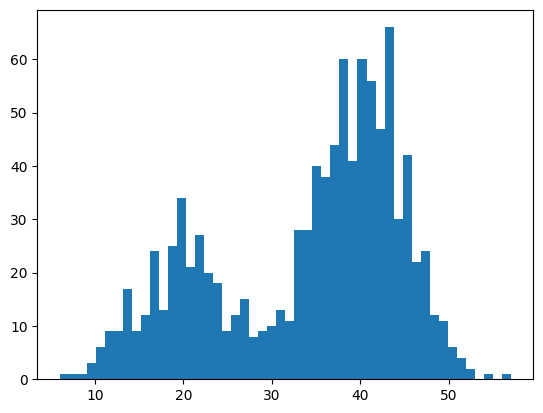

In [22]:
# plot histogram bins=50
plt.hist(sample,bins=50)

In [23]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=5, kernel='gaussian')

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))

model.fit(sample)

KernelDensity(bandwidth=5)

In [24]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

In [25]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

`score_samples(values)` returns the log-density estimate of the input samples values. This is because the `score_samples()` method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

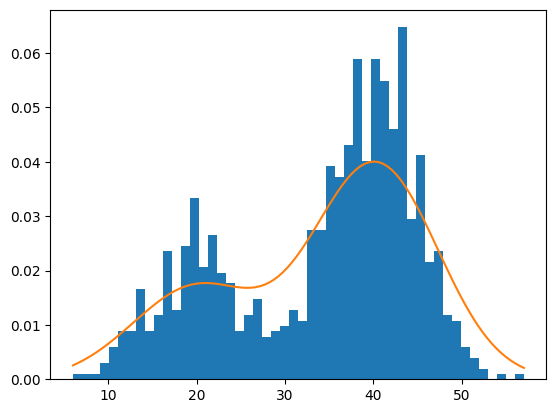

In [26]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

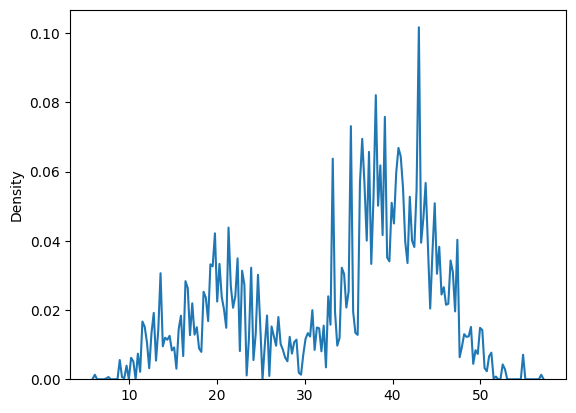

In [27]:
sns.kdeplot(sample.reshape(1000),bw_adjust=0.02)

In [28]:
import seaborn as sns

In [29]:
df = sns.load_dataset('iris')

In [30]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

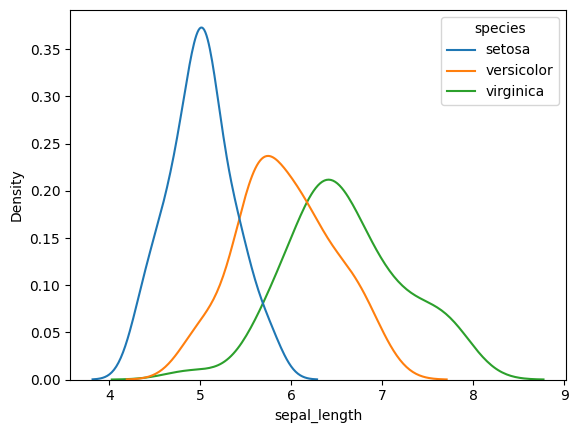

In [31]:
sns.kdeplot(data=df,x='sepal_length',hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

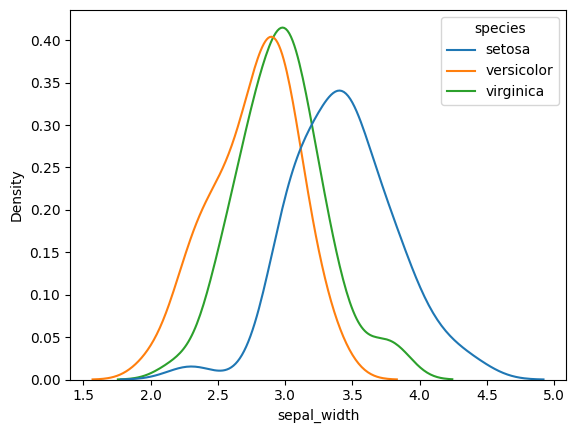

In [33]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

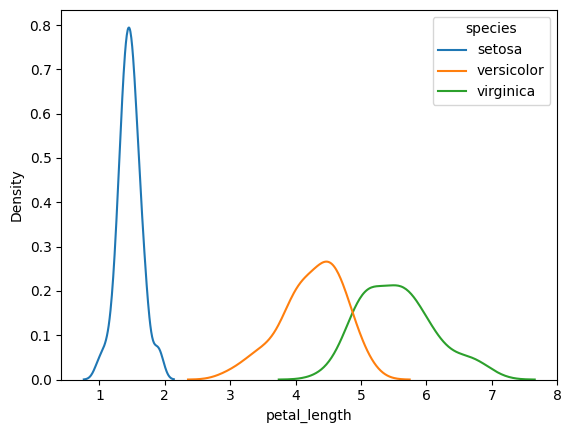

In [32]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

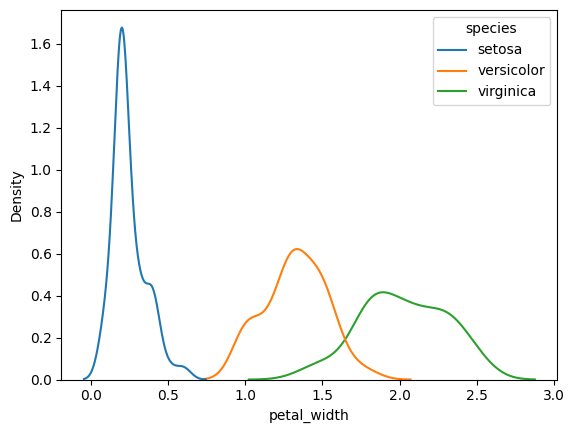

In [34]:
sns.kdeplot(data=df,x='petal_width',hue='species')

# Advanced Visualizations and Statistical Analysis
This section utilizes the `seaborn` library to explore the Iris and Titanic datasets. We use `jointplot` for bivariate distributions and `ecdfplot` to visualize the empirical cumulative distribution of features.

<Axes: xlabel='petal_width', ylabel='Density'>

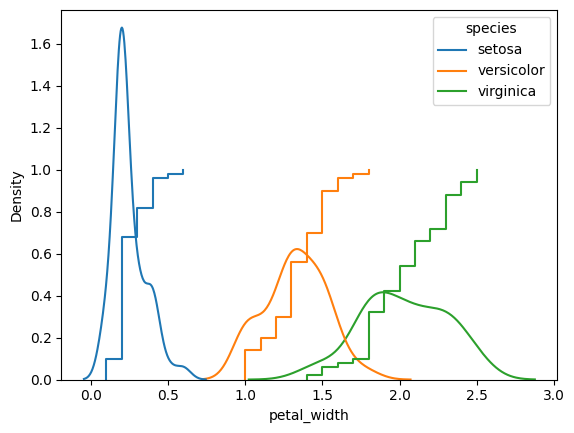

In [37]:
sns.kdeplot(data=df, x='petal_width', hue='species')
sns.ecdfplot(data=df,x='petal_width',hue='species')

In [36]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [38]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

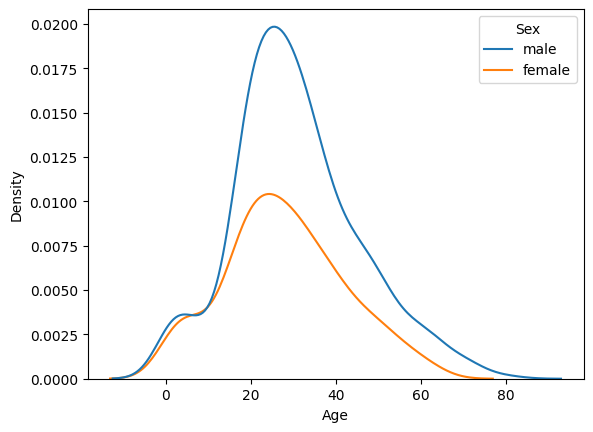

In [39]:
# code here
sns.kdeplot(data=titanic,x='Age',hue='Sex')

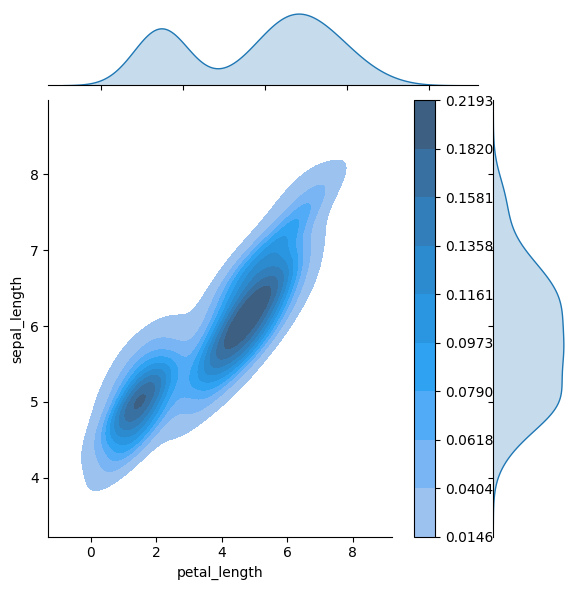

In [40]:
 sns.jointplot(data=df, x="petal_length", y="sepal_length", kind="kde",fill=True,cbar=True)

<Axes: xlabel='Age', ylabel='Density'>

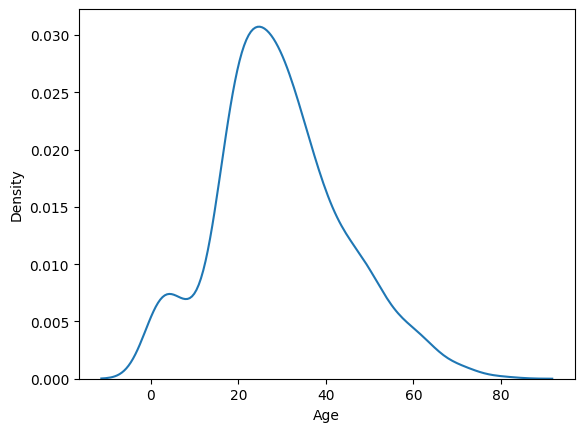

In [41]:
sns.kdeplot(titanic['Age'])

### Feature Scaling and Outlier Detection

**Standardization (Z-Score)**
We transform the 'Age' variable so it has a mean of 0 and a standard deviation of 1 using the formula:
$z = \frac{x - \mu}{\sigma}$

**Outlier Detection using the 3-Sigma Rule**
In a normal distribution, approximately 99.7% of the data falls within 3 standard deviations of the mean. Data points outside this range ($|z| > 3$) are often considered statistical outliers. Below, we identify passengers whose age is significantly higher than the average.

In [42]:
titanic['Age'].mean()

np.float64(29.69911764705882)

In [43]:
x = (titanic['Age'] - titanic['Age'].mean())/titanic['Age'].std()

<Axes: xlabel='Age', ylabel='Density'>

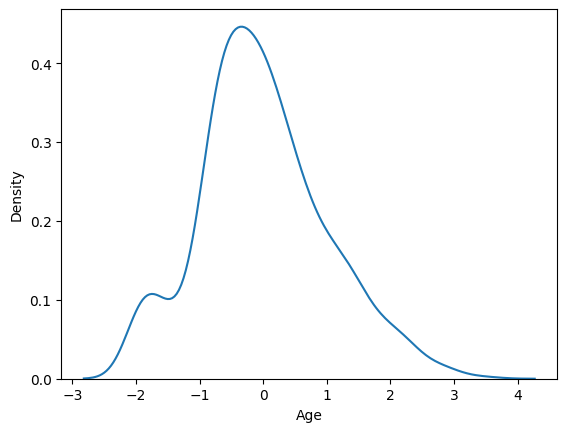

In [44]:
sns.kdeplot(x)

In [45]:
x.mean()

np.float64(2.388378943731429e-16)

In [46]:
x.std()

0.9999999999999994

In [47]:
titanic['Age'].skew()

np.float64(0.38910778230082704)

In [48]:
titanic['Age'].mean() + 3*titanic['Age'].std()

np.float64(73.27860964406095)

In [49]:
titanic['Age'].mean() - 3*titanic['Age'].std()

np.float64(-13.88037434994331)

In [50]:
titanic[titanic['Age'] > 73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [51]:
titanic['Age'].max()

80.0